# Análise Exploratória — PETR4 e Ibovespa

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

In [52]:
df_petr = pd.read_csv('dados/petr4_multivar.csv', parse_dates=['date'])
df_petr = df_petr.reset_index(drop=True)
df_petr_ind = pd.read_csv('dados/petr4_multivar_indicadores.csv', parse_dates=['date'])
df_petr_ind = df_petr_ind.reset_index(drop=True)
df_ibov = pd.read_csv('dados/ibov_multivar.csv', parse_dates=['date'])
df_ibov = df_ibov.reset_index(drop=True)
df_ibov_ind = pd.read_csv('dados/ibov_multivar_indicadores.csv', parse_dates=['date'])
df_ibov_ind = df_ibov_ind.reset_index(drop=True)

print('--- df_petr ---')
display(df_petr.head()); display(df_petr.tail())
print('--- df_petr_ind ---')
display(df_petr_ind.head()); display(df_petr_ind.tail())

print('--- df_ibov ---')
display(df_ibov.head()); display(df_ibov.tail())
print('--- df_ibov_ind ---')
display(df_ibov_ind.head()); display(df_ibov_ind.tail())

--- df_petr ---


,date,open,high,low,closed,vol,return
0,2010-01-05,37.38,37.43,36.80,37.00,794327744,-0.008574
1,2010-01-06,36.80,37.50,36.80,37.50,697345664,0.013514
2,2010-01-07,37.27,37.45,37.07,37.15,408386368,-0.009333
3,2010-01-08,37.16,37.39,36.86,36.95,542061952,-0.005384
4,2010-01-11,37.21,37.34,36.62,36.83,566849152,-0.003248


,date,open,high,low,closed,vol,return
4061,2026-05-25,43.49,43.82,42.97,43.40,1148437888,-0.024281
4062,2026-05-26,43.36,43.80,43.16,43.44,1564437248,0.000922
4063,2026-05-27,42.25,43.19,42.15,42.82,2297265152,-0.014273
4064,2026-05-28,43.10,43.18,42.24,42.51,1595417344,-0.007240
4065,2026-05-29,42.20,42.35,41.82,42.00,3077190912,-0.011997


--- df_petr_ind ---


,date,open,high,low,closed,vol,return,SMA_9,SMA_21,RSI
0,2010-02-03,34.05,34.18,33.73,34.04,546563520,-0.001760,34.256667,35.533333,32.203088
1,2010-02-04,33.84,33.94,32.12,32.30,798045312,-0.051116,34.031111,35.309524,22.445249
2,2010-02-05,31.80,32.27,30.72,31.52,911990336,-0.024149,33.672222,35.024762,19.580941
3,2010-02-08,31.80,32.26,31.42,31.74,595332608,0.006980,33.432222,34.767143,22.581837
4,2010-02-09,32.20,32.68,32.10,32.24,585596672,0.015753,33.224444,34.542857,29.060864


...

,date,open,high,low,closed,vol,return
0,2010-01-05,70045,70594,69927,70239,5291956224,0.002770
1,2010-01-06,70236,70936,70016,70729,5347834368,0.006976
2,2010-01-07,70722,70722,70045,70451,4432724480,-0.003930
3,2010-01-08,70455,70765,70158,70262,4366168064,-0.002683
4,2010-01-11,70267,71068,70158,70433,4133910784,0.002434


,date,open,high,low,closed,vol,return
4058,2026-05-25,176210,177816,176210,177816,9995857808,0.009114
4059,2026-05-26,177816,177816,175516,176589,16507269684,-0.006900
4060,2026-05-27,176602,177640,175555,175744,16376190208,-0.004785
4061,2026-05-28,175744,176627,174686,175063,15601763363,-0.003875
4062,2026-05-29,175064,175064,172686,173787,36949217845,-0.007289


--- df_ibov_ind ---


,date,open,high,low,closed,vol,return,SMA_9,SMA_21,RSI
0,2010-02-03,67163,67346,66774,67108,4452461568,-0.000819,66101.333333,68274.904762,41.492157
1,2010-02-04,67100,67100,63749,63934,5750446080,-0.047297,65841.777778,67974.666667,27.043204
2,2010-02-05,63934,64000,61341,62762,6866149376,-0.018331,65457.555556,67595.285714,23.753855
3,2010-02-08,62759,63922,62727,63153,4571245568,0.006230,65194.222222,67247.761905,26.946331
4,2010-02-09,63163,65525,63163,64718,5783735296,0.024781,65155.222222,66983.761905,38.115347


,date,open,high,low,closed,vol,return,SMA_9,SMA_21,RSI
4038,2026-05-25,176210,177816,176210,177816,9995857808,0.009114,177003.888889,182079.428571,39.987703
4039,2026-05-26,177816,177816,175516,176589,16507269684,-0.006900,176947.333333,181405.333333,37.901676
4040,2026-05-27,176602,177640,175555,175744,16376190208,-0.004785,176656.000000,180746.523810,36.489909
4041,2026-05-28,175744,176627,174686,175063,15601763363,-0.003875,176409.222222,180101.000000,35.347202
4042,2026-05-29,175064,175064,172686,173787,36949217845,-0.007289,176054.888889,179578.952381,33.246355


## 1. Histórico de preços de fechamento — PETR4

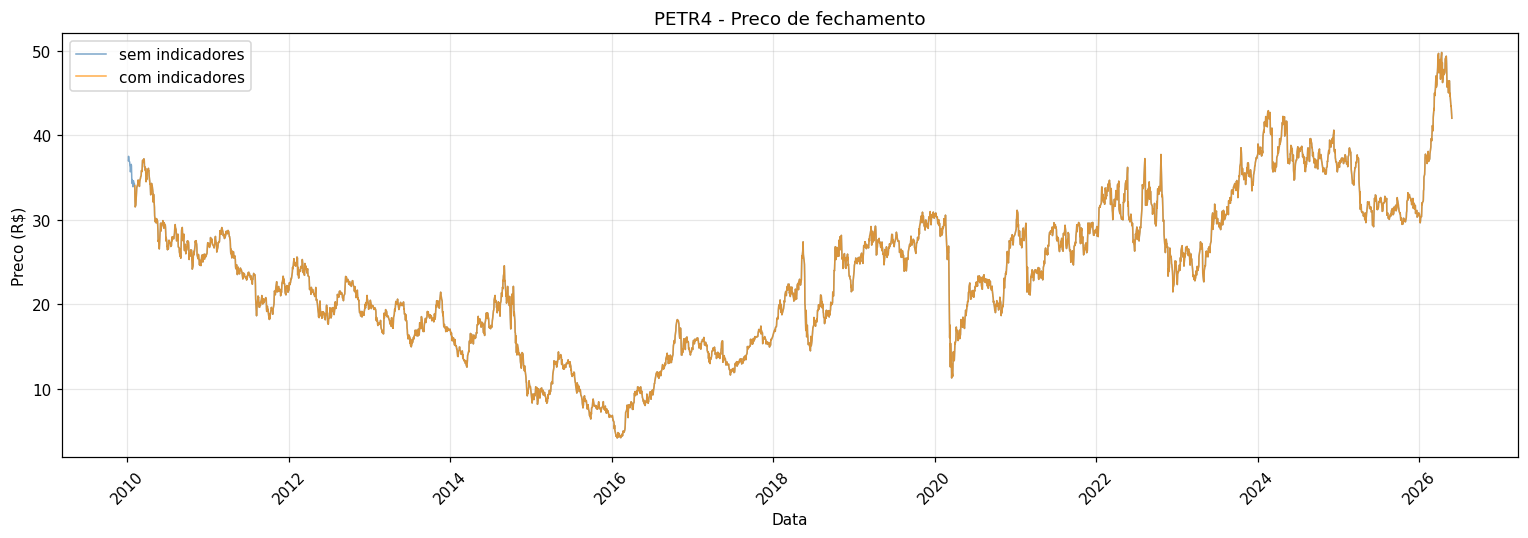

In [53]:
plt.figure(figsize=(14, 5))
plt.plot(df_petr['date'], df_petr['closed'], linewidth=1.0, color='steelblue', alpha=0.7, label='sem indicadores')
plt.plot(df_petr_ind['date'], df_petr_ind['closed'], linewidth=1.0, color='darkorange', alpha=0.7, label='com indicadores')
plt.title('PETR4 - Preco de fechamento')
plt.xlabel('Data')
plt.ylabel('Preco (R$)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Histórico de preços de fechamento — Ibovespa (a partir de 2010)

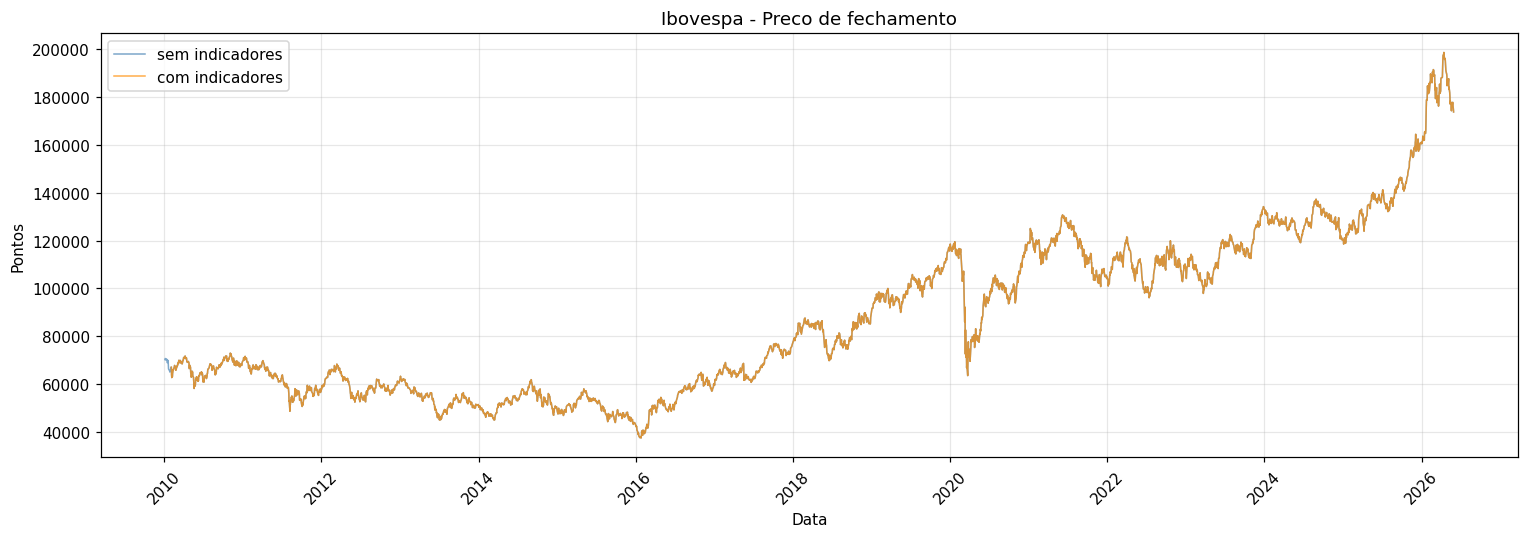

In [54]:
plt.figure(figsize=(14, 5))
plt.plot(df_ibov['date'], df_ibov['closed'], linewidth=1.0, color='steelblue', alpha=0.7, label='sem indicadores')
plt.plot(df_ibov_ind['date'], df_ibov_ind['closed'], linewidth=1.0, color='darkorange', alpha=0.7, label='com indicadores')
plt.title('Ibovespa - Preco de fechamento')
plt.xlabel('Data')
plt.ylabel('Pontos')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Estatísticas descritivas

In [55]:
print('=== PETR4 — petr4_multivar.csv ===')
display(df_petr.describe())

print('\n=== PETR4 — petr4_multivar_indicadores.csv ===')
display(df_petr_ind.describe())

=== PETR4 — petr4_multivar.csv ===


,date,open,high,low,closed,vol,return
count,4066,4066.000000,4066.000000,4066.000000,4066.000000,4.066000e+03,4066.000000
mean,2018-03-20 10:39:36.389572,23.840015,24.167700,23.497664,23.822076,1.146417e+09,0.000412
min,2010-01-05 00:00:00,4.200000,4.270000,4.120000,4.200000,6.272422e+07,-0.296978
25%,2014-02-10 06:00:00,17.442500,17.772500,17.120000,17.352500,5.197182e+08,-0.012779
50%,2018-03-22 12:00:00,23.920000,24.195000,23.525000,23.875000,8.847576e+08,0.000809
75%,2022-05-02 18:00:00,29.850000,30.195000,29.477500,29.757500,1.494899e+09,0.013716
max,2026-05-29 00:00:00,50.070000,50.690000,49.490000,49.780000,1.080373e+10,0.222222
std,NaN,8.758078,8.825235,8.698633,8.768758,8.808403e+08,0.027502



=== PETR4 — petr4_multivar_indicadores.csv ===


,date,open,high,low,closed,vol,return,SMA_9,SMA_21,RSI
count,4046,4046.000000,4046.000000,4046.000000,4046.000000,4.046000e+03,4046.000000,4046.000000,4046.000000,4046.000000
mean,2018-04-04 04:34:02.906574,23.781060,24.109066,23.439412,23.763816,1.148880e+09,0.000436,23.755130,23.740517,50.876738
min,2010-02-03 00:00:00,4.200000,4.270000,4.120000,4.200000,6.272422e+07,-0.296978,4.445556,4.508095,15.301578
25%,2014-03-05 06:00:00,17.402500,17.750000,17.100000,17.320000,5.188094e+08,-0.012780,17.444444,17.530833,42.051040
50%,2018-04-07 12:00:00,23.825000,24.135000,23.470000,23.800000,8.875285e+08,0.000833,23.855000,23.825952,50.787827
75%,2022-05-09 18:00:00,29.747500,30.100000,29.337500,29.660000,1.498839e+09,0.013751,29.718611,29.740357,59.348499
max,2026-05-29 00:00:00,50.070000,50.690000,49.490000,49.780000,1.080373e+10,0.222222,48.471111,48.049524,86.231174
std,NaN,8.738982,8.807059,8.680032,8.750662,8.822727e+08,0.027550,8.706148,8.635596,12.170992


In [56]:
print('=== Ibovespa — ibov_multivar.csv ===')
display(df_ibov.describe())

print('\n=== Ibovespa — ibov_multivar_indicadores.csv ===')
display(df_ibov_ind.describe())

=== Ibovespa — ibov_multivar.csv ===


,date,open,high,low,closed,vol,return
count,4063,4063.000000,4063.000000,4063.000000,4063.000000,4.063000e+03,4063.000000
mean,2018-03-20 07:08:50.740832,87076.671179,87845.060546,86330.050209,87100.851834,8.165949e+09,0.000330
min,2010-01-05 00:00:00,37500.000000,38031.000000,37046.000000,37497.000000,0.000000e+00,-0.147797
25%,2014-02-10 12:00:00,57784.000000,58363.000000,57291.500000,57758.500000,3.918285e+09,-0.007448
50%,2018-03-22 00:00:00,76587.000000,77232.000000,75697.000000,76591.000000,5.553046e+09,0.000363
75%,2022-04-30 12:00:00,113635.000000,114558.000000,112603.000000,113643.500000,1.128971e+10,0.008312
max,2026-05-29 00:00:00,198657.000000,199355.000000,198001.000000,198657.000000,5.432121e+10,0.139082
std,NaN,33301.339256,33498.768766,33133.121236,33327.907657,7.764818e+09,0.014524



=== Ibovespa — ibov_multivar_indicadores.csv ===


,date,open,high,low,closed,vol,return,SMA_9,SMA_21,RSI
count,4043,4043.000000,4043.000000,4043.000000,4043.000000,4.043000e+03,4043.000000,4043.000000,4043.000000,4043.000000
mean,2018-04-04 01:18:00.089042,87168.684887,87938.575810,86421.921098,87193.691813,8.183193e+09,0.000341,87085.232775,86921.995077,52.091154
min,2010-02-03 00:00:00,37500.000000,38031.000000,37046.000000,37497.000000,0.000000e+00,-0.147797,38051.000000,39070.952381,13.532056
25%,2014-03-05 12:00:00,57717.000000,58322.500000,57258.000000,57708.500000,3.915082e+09,-0.007448,57762.611111,57587.523810,43.186075
50%,2018-04-06 00:00:00,76779.000000,78008.000000,76046.000000,76789.000000,5.572240e+09,0.000374,76614.000000,76627.904762,51.521291
75%,2022-05-07 12:00:00,113750.500000,114744.000000,112685.000000,113755.500000,1.134198e+10,0.008330,113425.222222,113436.333333,60.907809
max,2026-05-29 00:00:00,198657.000000,199355.000000,198001.000000,198657.000000,5.432121e+10,0.139082,196491.444444,192042.904762,87.455688
std,NaN,33357.536257,33554.803024,33188.822680,33383.729817,7.780004e+09,0.014538,33242.217566,33015.703249,12.086016


## 4. Distribuição dos retornos diários

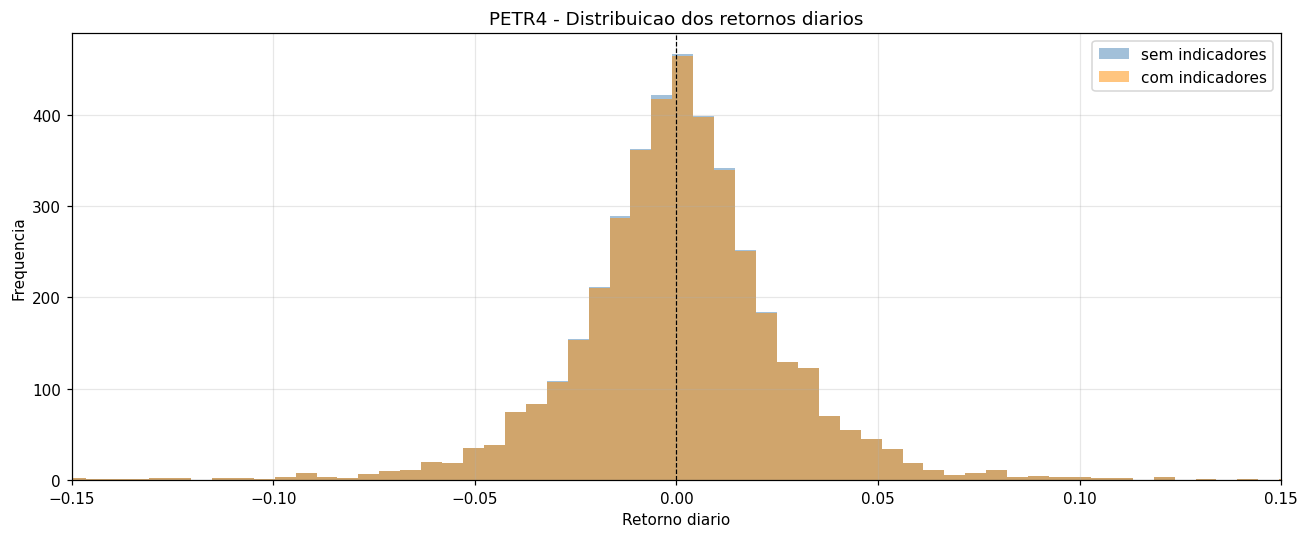

In [57]:
plt.figure(figsize=(12, 5))
sns.histplot(df_petr['return'].dropna(), bins=100, color='steelblue', alpha=0.5, edgecolor='none', label='sem indicadores')
sns.histplot(df_petr_ind['return'].dropna(), bins=100, color='darkorange', alpha=0.5, edgecolor='none', label='com indicadores')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('PETR4 - Distribuicao dos retornos diarios')
plt.xlabel('Retorno diario')
plt.ylabel('Frequencia')
plt.xlim(-0.15, 0.15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

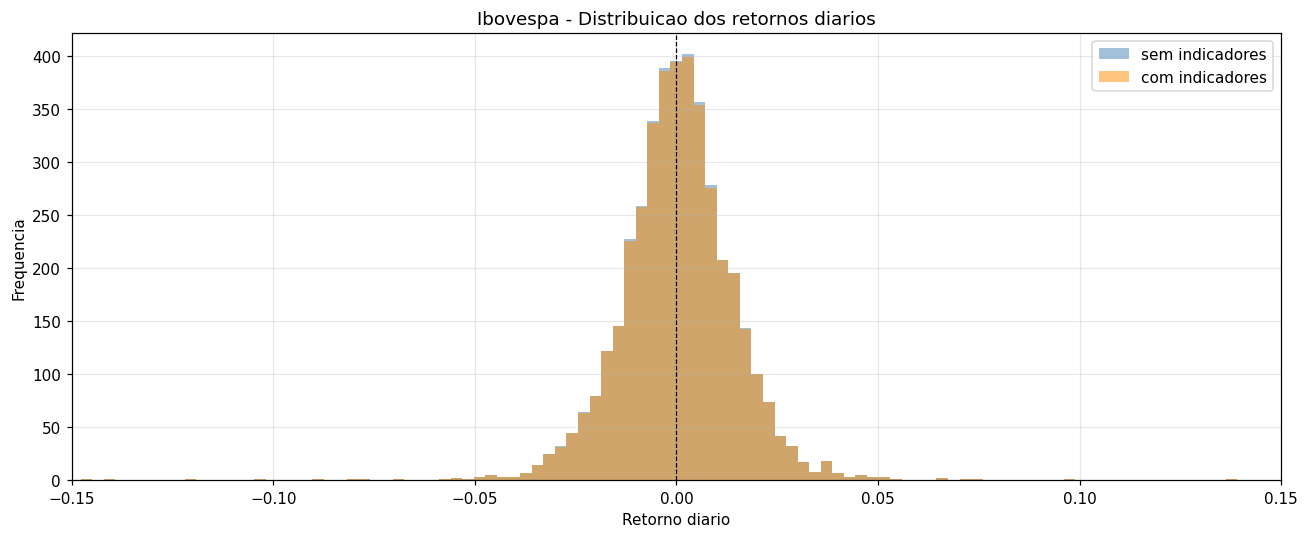

In [58]:
plt.figure(figsize=(12, 5))
sns.histplot(df_ibov['return'].dropna(), bins=100, color='steelblue', alpha=0.5, edgecolor='none', label='sem indicadores')
sns.histplot(df_ibov_ind['return'].dropna(), bins=100, color='darkorange', alpha=0.5, edgecolor='none', label='com indicadores')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Ibovespa - Distribuicao dos retornos diarios')
plt.xlabel('Retorno diario')
plt.ylabel('Frequencia')
plt.xlim(-0.15, 0.15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Série temporal dos retornos diários

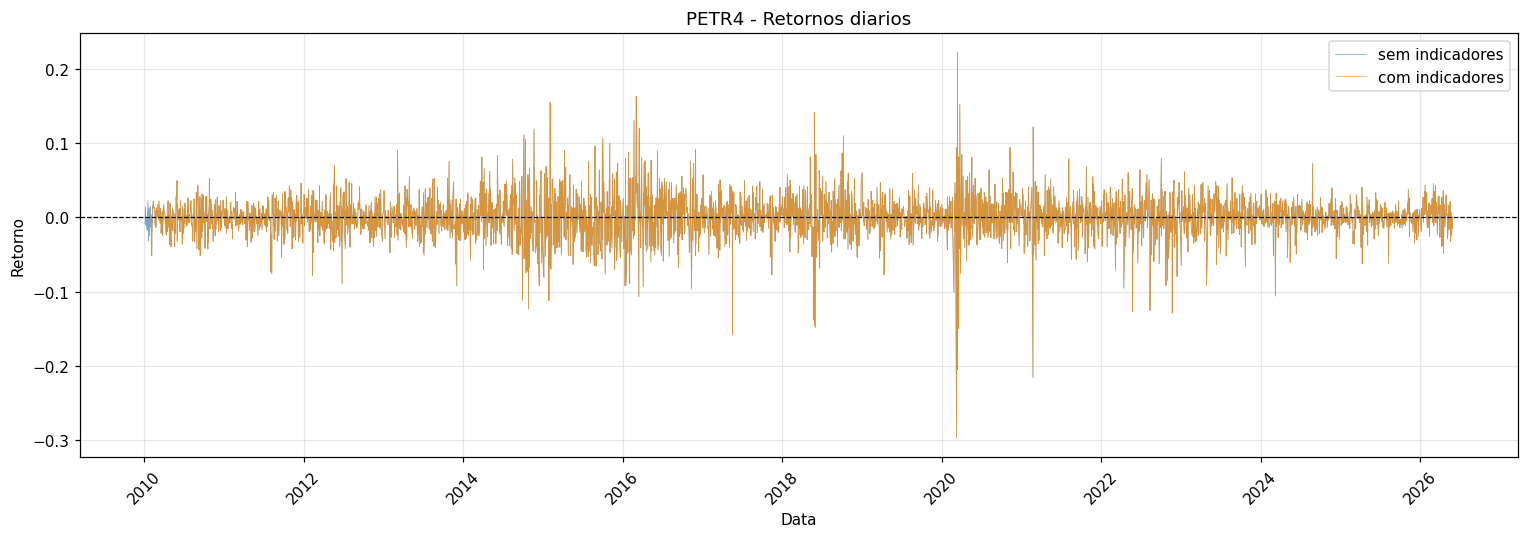

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(df_petr['date'], df_petr['return'], linewidth=0.5, color='steelblue', alpha=0.7, label='sem indicadores')
plt.plot(df_petr_ind['date'], df_petr_ind['return'], linewidth=0.5, color='darkorange', alpha=0.7, label='com indicadores')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('PETR4 - Retornos diarios')
plt.xlabel('Data')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

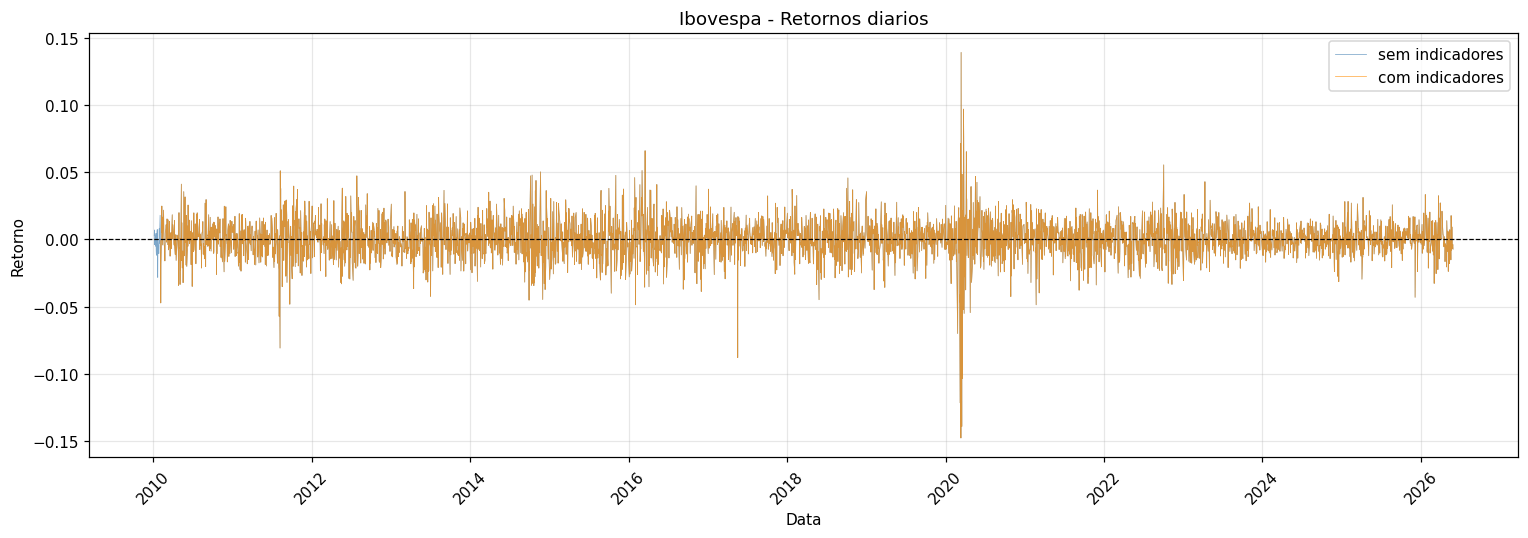

In [60]:
plt.figure(figsize=(14, 5))
plt.plot(df_ibov['date'], df_ibov['return'], linewidth=0.5, color='steelblue', alpha=0.7, label='sem indicadores')
plt.plot(df_ibov_ind['date'], df_ibov_ind['return'], linewidth=0.5, color='darkorange', alpha=0.7, label='com indicadores')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Ibovespa - Retornos diarios')
plt.xlabel('Data')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()